# MovieLens: Polars vs Pandas para Análisis y Predicción de Preferencias de Películas
El objetivo de este proyecto es construir un pipeline completo utilizando Polars para análisis de datos, ingeniería de características y aprendizaje automático, comparándolo posteriormente con una implementación equivalente en Pandas para evaluar rendimiento y escalabilidad.

## Configuración del entorno

### Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import polars as pl
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_ratings_polars,
    load_movies_polars,
    get_dataset_info,
    get_missing_values,
    get_dataset_size,
    get_system_info,
)

from src.polars_pipeline import run_polars_pipeline
from src.pandas_pipeline import run_pandas_pipeline

from src.train_models import train_all_models

### Información del Sistema

In [2]:
system_info = get_system_info()

for key, value in system_info.items():
    print(f"{key:<20}: {value}")

cpu_cores           : 8
total_ram_gb        : 16.0


## Carga de datos
En esta sección se cargan los datasets ratings.csv y movies.csv utilizando Polars. Además, se presenta información general sobre el tamaño y la estructura de ambos conjuntos de datos, con el objetivo de verificar que la información se haya cargado correctamente antes de iniciar el análisis exploratorio.

In [3]:
ratings = load_ratings_polars("../data/raw/ratings.csv")
movies = load_movies_polars("../data/raw/movies.csv")

In [4]:
ratings_info = get_dataset_info(ratings)
movies_info = get_dataset_info(movies)

print(ratings_info)
print(movies_info)

{'rows': 100836, 'columns': 4, 'column_names': ['userId', 'movieId', 'rating', 'timestamp']}
{'rows': 86537, 'columns': 3, 'column_names': ['movieId', 'title', 'genres']}


## EDA

### Descripción General del Dataset

In [5]:
ratings_info = get_dataset_info(ratings)
movies_info = get_dataset_info(movies)

pd.DataFrame([
    {
        "Dataset": "Ratings",
        "Rows": ratings_info["rows"],
        "Columns": ratings_info["columns"],
        "Size (MB)": get_dataset_size("../data/raw/ratings.csv"),
    },
    {
        "Dataset": "Movies",
        "Rows": movies_info["rows"],
        "Columns": movies_info["columns"],
        "Size (MB)": get_dataset_size("../data/raw/movies.csv"),
    }
])

,Dataset,Rows,Columns,Size (MB)
0,Ratings,100836,4,2.368663
1,Movies,86537,3,3.998122


El dataset ratings contiene las calificaciones otorgadas por los usuarios, mientras que movies almacena la información descriptiva de cada película. Ambos conjuntos se relacionan mediante la columna movieId.

### Estadísticas Descriptivas

In [6]:
ratings.describe()

statistic,userId,movieId,rating,timestamp
str,f64,f64,f64,f64
"""count""",100836.0,100836.0,100836.0,100836.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",326.127564,19435.295718,3.501557,1.2059e9
"""std""",182.618491,35530.987199,1.042529,2.1626e8
"""min""",1.0,1.0,0.5,8.28124615e8
"""25%""",177.0,1199.0,3.0,1.0191e9
"""50%""",325.0,2991.0,3.5,1.1861e9
"""75%""",477.0,8121.0,4.0,1.4360e9
"""max""",610.0,193609.0,5.0,1.5378e9


In [7]:
print(f"Unique Users   : {ratings['userId'].n_unique()}")
print(f"Unique Movies  : {ratings['movieId'].n_unique()}")
print(f"Average Rating : {ratings['rating'].mean():.2f}")
print(f"Total Ratings  : {ratings.shape[0]:,}")

Unique Users   : 610
Unique Movies  : 9724
Average Rating : 3.50
Total Ratings  : 100,836


### Missing Values

In [8]:
missing_ratings = get_missing_values(ratings)

missing_ratings

userId,movieId,rating,timestamp
u32,u32,u32,u32
0,0,0,0


In [9]:
missing_movies = get_missing_values(movies)

missing_movies

movieId,title,genres
u32,u32,u32
0,0,0


### Distribución de Ratings

In [10]:
rating_counts = (
    ratings
    .group_by("rating")
    .len()
    .sort("rating")
)

rating_counts

rating,len
f64,u32
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


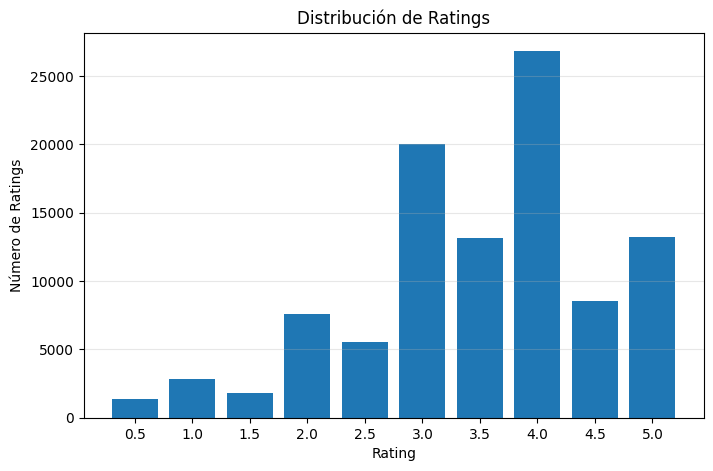

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_counts["rating"],
    rating_counts["len"],
    width=0.4
)

plt.xticks(rating_counts["rating"])

plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Número de Ratings")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Análisis de Usuarios

In [12]:
user_activity = (
    ratings
    .group_by("userId")
    .len()
)

In [13]:
user_activity.describe()

statistic,userId,len
str,f64,f64
"""count""",610.0,610.0
"""null_count""",0.0,0.0
"""mean""",305.5,165.304918
"""std""",176.236111,269.480584
"""min""",1.0,20.0
"""25%""",153.0,35.0
"""50%""",306.0,71.0
"""75%""",458.0,168.0
"""max""",610.0,2698.0


### Análisis de Películas

In [14]:
movie_activity = (
    ratings
    .group_by("movieId")
    .len()
)

In [15]:
movie_activity.describe()

statistic,movieId,len
str,f64,f64
"""count""",9724.0,9724.0
"""null_count""",0.0,0.0
"""mean""",42245.024373,10.369807
"""std""",52191.13732,22.401005
"""min""",1.0,1.0
"""25%""",3246.0,1.0
"""50%""",7301.0,3.0
"""75%""",76738.0,9.0
"""max""",193609.0,329.0


### Distribución de Géneros

In [16]:
genre_counts = (
    movies
    .with_columns(
        pl.col("genres").str.split("|")
    )
    .explode("genres")
    .group_by("genres")
    .len(name="movie_count")
    .sort("movie_count", descending=True)
)

genre_counts

genres,movie_count
str,u32
"""Drama""",33681
"""Comedy""",22830
"""Thriller""",11675
"""Romance""",10172
"""Action""",9563
…,…
"""War""",2301
"""Western""",1690
"""Musical""",1059


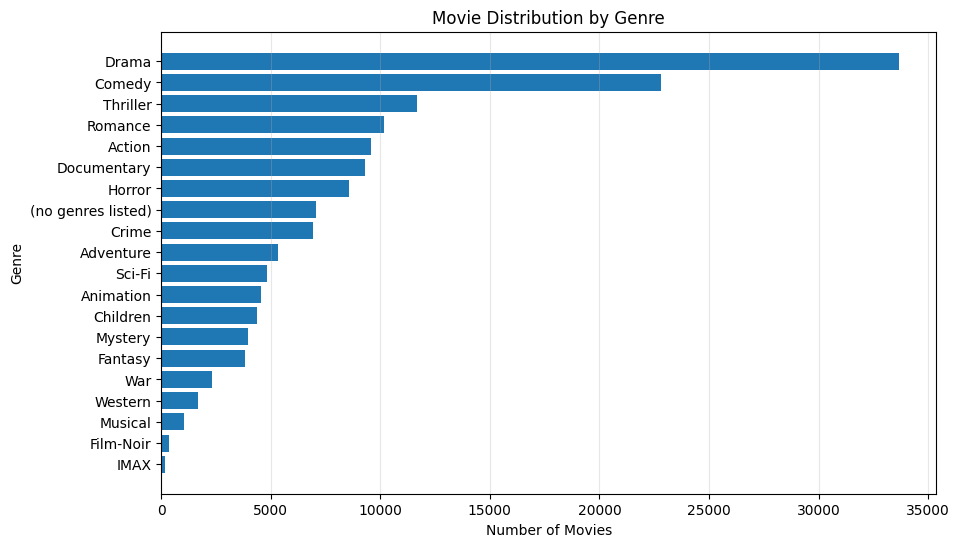

In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    genre_counts["genres"],
    genre_counts["movie_count"]
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.title("Movie Distribution by Genre")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Principales hallazgos del EDA

- El conjunto de datos contiene 100,836 calificaciones, realizadas por 610 usuarios sobre 9,724 películas, proporcionando un volumen adecuado para el desarrollo de modelos de Machine Learning.
- No se identificaron valores faltantes en ninguno de los datasets, por lo que no será necesario realizar procesos de imputación durante el preprocesamiento.
- Las calificaciones presentan una mayor concentración entre 3.0 y 5.0, siendo 4.0 la valoración más frecuente. Esto respalda la definición de una valoración positiva como aquellas con rating ≥ 4.0.
- La actividad de los usuarios es altamente heterogénea, existiendo usuarios con pocas calificaciones y otros con miles de valoraciones registradas.
- La popularidad de las películas también presenta una distribución desigual, donde la mayoría recibe pocas calificaciones mientras que un reducido grupo concentra gran parte de las interacciones.
- El dataset incluye una amplia diversidad de géneros cinematográficos. Debido a que una película puede pertenecer a múltiples géneros, será necesario transformar esta información en variables binarias durante la etapa de ingeniería de características.

## Pipeline Polars

### Ejecución del pipeline

In [18]:
(
    train_df,
    test_df,
    X_train,
    X_test,
    y_train,
    y_test,
    timings_polars,
) = run_polars_pipeline(
    ratings_path="../data/raw/ratings.csv",
    movies_path="../data/raw/movies.csv",
)

### Resultados del Preprocesamiento

In [19]:
print(f"Training samples : {train_df.height:,}")
print(f"Testing samples  : {test_df.height:,}")

print(f"Training features: {train_df.width}")
print(f"Testing features : {test_df.width}")

Training samples : 80,200
Testing samples  : 20,050
Training features: 27
Testing features : 27


In [20]:
print("Training Set")
display(
    train_df
    .group_by("liked_movie")
    .len()
    .sort("liked_movie")
)

print("Testing Set")
display(
    test_df
    .group_by("liked_movie")
    .len()
    .sort("liked_movie")
)

Training Set


liked_movie,len
i8,u32
0,41574
1,38626


Testing Set


liked_movie,len
i8,u32
0,10393
1,9657


### Resultados Feature Engineering

In [21]:
feature_columns = [
    "user_avg_rating",
    "user_num_ratings",
    "movie_avg_rating",
    "movie_num_ratings",
]

train_df.select(feature_columns).head()

user_avg_rating,user_num_ratings,movie_avg_rating,movie_num_ratings
f64,i32,f64,i32
4.081169,154,3.90411,73
3.883495,103,3.961538,117
3.968085,94,3.8,5
3.435233,386,3.5,1
3.9,30,4.170775,284


In [22]:
genre_features = [
    column
    for column in train_df.columns
    if column.startswith("genre_")
]

print(f"Genre Features ({len(genre_features)}):")

genre_features

Genre Features (20):


['genre_(no_genres_listed)',
 'genre_action',
 'genre_adventure',
 'genre_animation',
 'genre_children',
 'genre_comedy',
 'genre_crime',
 'genre_documentary',
 'genre_drama',
 'genre_fantasy',
 'genre_film_noir',
 'genre_horror',
 'genre_imax',
 'genre_musical',
 'genre_mystery',
 'genre_romance',
 'genre_sci_fi',
 'genre_thriller',
 'genre_war',
 'genre_western']

In [23]:
print(f"Total Features: {len(train_df.columns)}")

Total Features: 27


### Entrenamiento de Modelos

In [24]:
results_polars = train_all_models(
    X_train,
    X_test,
    y_train,
    y_test,
)

### Comparación de Modelos

In [25]:
comparison_polars = pl.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "F1 Score": r["f1_score"],
        "ROC AUC": r["auc"],
        "Training Time (s)": r["training_time"],
    }
    for r in results_polars
]).sort(
    "Accuracy",
    descending=True,
)

comparison_polars

Model,Accuracy,F1 Score,ROC AUC,Training Time (s)
str,f64,f64,f64,f64
"""Random Forest""",0.703242,0.689133,0.76727,1.037286
"""Gradient Boosting""",0.698653,0.688267,0.757459,6.341188
"""Logistic Regression""",0.694763,0.682934,0.75349,0.037803


### Matrices de Confusión

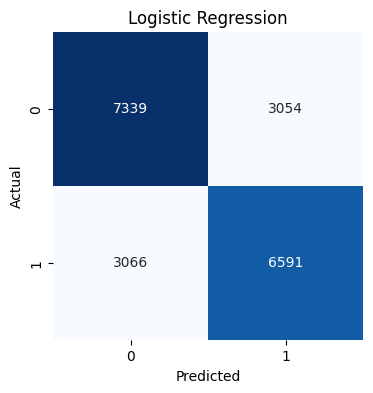

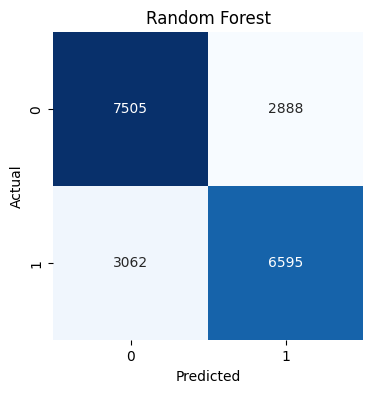

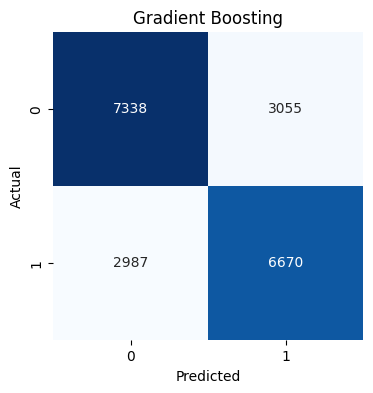

In [26]:
for result in results_polars:

    plt.figure(figsize=(4,4))

    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
    )

    plt.title(result["model"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### Métricas del Pipeline

In [27]:
pl.DataFrame(
    {
        "Operation": list(timings_polars.keys()),
        "Time (seconds)": list(timings_polars.values()),
    }
)

Operation,Time (seconds)
str,f64
"""loading""",0.004259
"""join""",0.002174
"""filtering""",0.000534
"""missing_values""",0.000477
"""target""",0.000159
"""feature_engineering""",0.022578
"""total""",0.030181


## Pipeline Pandas

### Ejecución del pipeline

In [28]:
(
    train_df_pd,
    test_df_pd,
    X_train_pd,
    X_test_pd,
    y_train_pd,
    y_test_pd,
    timings_pandas,
) = run_pandas_pipeline(
    ratings_path="../data/raw/ratings.csv",
    movies_path="../data/raw/movies.csv",
)

/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To

### Resultados del Preprocesamiento

In [29]:
print(f"Training samples : {len(train_df_pd):,}")
print(f"Testing samples  : {len(test_df_pd):,}")

print(f"Training features: {train_df_pd.shape[1]}")
print(f"Testing features : {test_df_pd.shape[1]}")

Training samples : 80,200
Testing samples  : 20,050
Training features: 27
Testing features : 27


In [30]:
display(
    train_df_pd["liked_movie"]
    .value_counts()
    .rename_axis("liked_movie")
    .reset_index(name="count")
)

,liked_movie,count
0,0,41574
1,1,38626


In [31]:
display(
    test_df_pd["liked_movie"]
    .value_counts()
    .rename_axis("liked_movie")
    .reset_index(name="count")
)

,liked_movie,count
0,0,10393
1,1,9657


### Resultados Feature Engineering

In [32]:
feature_columns = [
    "user_avg_rating",
    "user_num_ratings",
    "movie_avg_rating",
    "movie_num_ratings",
]

train_df_pd[feature_columns].head()

,user_avg_rating,user_num_ratings,movie_avg_rating,movie_num_ratings
0,4.081169,154,3.904110,73
1,3.883495,103,3.961538,117
2,3.968085,94,3.800000,5
3,3.435233,386,3.500000,1
4,3.900000,30,4.170775,284


In [33]:
genre_features = [
    column
    for column in train_df_pd.columns
    if column.startswith("genre_")
]

print(f"Genre Features ({len(genre_features)}):")

genre_features

Genre Features (20):


['genre_(no_genres_listed)',
 'genre_action',
 'genre_adventure',
 'genre_animation',
 'genre_children',
 'genre_comedy',
 'genre_crime',
 'genre_documentary',
 'genre_drama',
 'genre_fantasy',
 'genre_film_noir',
 'genre_horror',
 'genre_imax',
 'genre_musical',
 'genre_mystery',
 'genre_romance',
 'genre_sci_fi',
 'genre_thriller',
 'genre_war',
 'genre_western']

In [34]:
print(f"Total Features: {train_df_pd.shape[1]}")

Total Features: 27


### Entrenamiento de Modelos

In [35]:
results_pandas = train_all_models(
    X_train_pd,
    X_test_pd,
    y_train_pd,
    y_test_pd,
)

### Comparación de Modelos

In [36]:
comparison_pandas = pd.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "F1 Score": r["f1_score"],
        "ROC AUC": r["auc"],
        "Training Time (s)": r["training_time"],
    }
    for r in results_pandas
]).sort_values(
    by="Accuracy",
    ascending=False,
)
comparison_pandas

,Model,Accuracy,F1 Score,ROC AUC,Training Time (s)
1,Random Forest,0.703242,0.689133,0.767270,1.079507
2,Gradient Boosting,0.698653,0.688267,0.757459,6.359028
0,Logistic Regression,0.694763,0.682934,0.753490,0.032771


### Matrices de Confusión

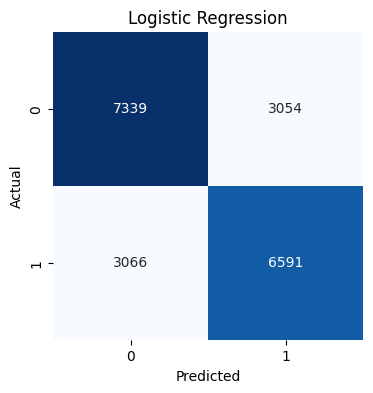

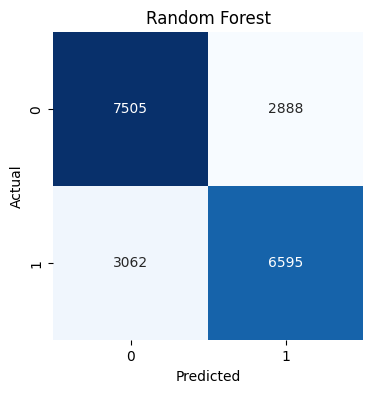

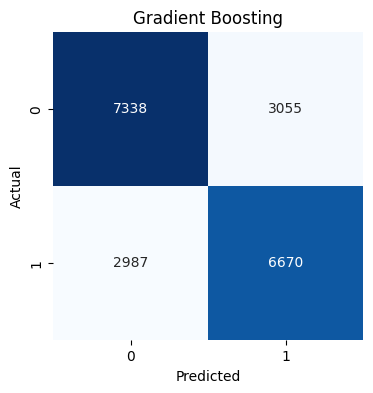

In [38]:
for result in results_pandas:

    plt.figure(figsize=(4,4))

    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
    )

    plt.title(result["model"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### Métricas del Pipeline

In [39]:
pd.DataFrame(
    {
        "Operation": list(timings_pandas.keys()),
        "Time (seconds)": list(timings_pandas.values()),
    }
)

,Operation,Time (seconds)
0,loading,0.062124
1,join,0.004949
2,filtering,0.001295
3,missing_values,0.004869
4,target,0.001762
5,feature_engineering,0.541590
6,total,0.616590


## Benchmark Polars vs Pandas

In [40]:
benchmark = pd.DataFrame(
    {
        "Operation": list(timings_polars.keys()),
        "Polars (s)": list(timings_polars.values()),
        "Pandas (s)": list(timings_pandas.values()),
    }
)

benchmark["Difference (s)"] = (
    benchmark["Pandas (s)"] -
    benchmark["Polars (s)"]
)

benchmark

,Operation,Polars (s),Pandas (s),Difference (s)
0,loading,0.004259,0.062124,0.057865
1,join,0.002174,0.004949,0.002775
2,filtering,0.000534,0.001295,0.000762
3,missing_values,0.000477,0.004869,0.004392
4,target,0.000159,0.001762,0.001602
5,feature_engineering,0.022578,0.541590,0.519012
6,total,0.030181,0.616590,0.586409


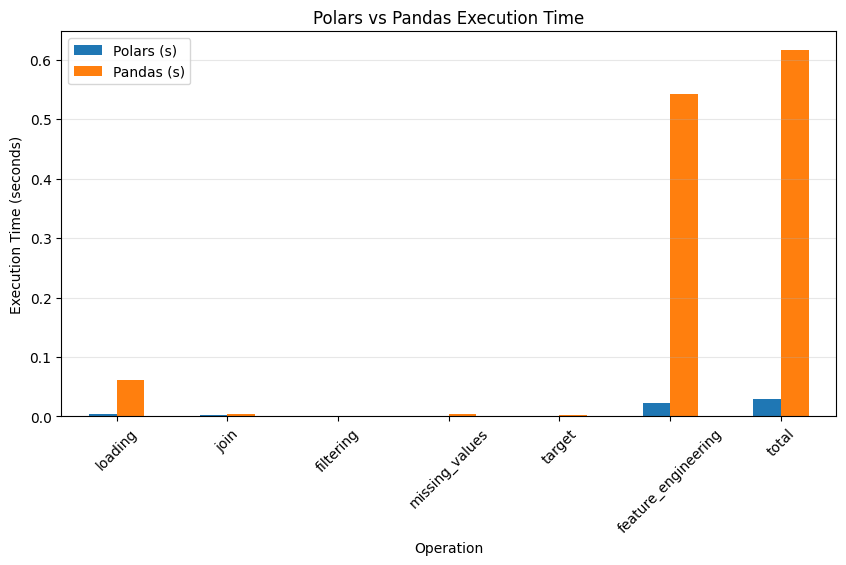

In [41]:
benchmark_plot = benchmark.set_index("Operation")

benchmark_plot[
    ["Polars (s)", "Pandas (s)"]
].plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Execution Time (seconds)")
plt.title("Polars vs Pandas Execution Time")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Escalabilidad

In [42]:
from pathlib import Path

fractions = [0.25, 0.50, 0.75, 1.00]

temp_dir = Path("../data/scalability")
temp_dir.mkdir(exist_ok=True)

ratings_original = load_ratings_polars("../data/raw/ratings.csv")
movies_original = load_movies_polars("../data/raw/movies.csv")

movies_original.write_csv(
    temp_dir / "movies.csv"
)

for fraction in fractions:

    subset = ratings_original.sample(
        fraction=fraction,
        seed=42,
        shuffle=False,
    )

    subset.write_csv(
        temp_dir /
        f"ratings_{int(fraction*100)}.csv"
    )

In [43]:
scalability_results = []

for fraction in fractions:

    ratings_path = (
        temp_dir /
        f"ratings_{int(fraction*100)}.csv"
    )

    (
        _,
        _,
        _,
        _,
        _,
        _,
        timings_polars,
    ) = run_polars_pipeline(
        ratings_path=str(ratings_path),
        movies_path=str(temp_dir / "movies.csv"),
    )

    (
        _,
        _,
        _,
        _,
        _,
        _,
        timings_pandas,
    ) = run_pandas_pipeline(
        ratings_path=str(ratings_path),
        movies_path=str(temp_dir / "movies.csv"),
    )

    rows = pl.read_csv(ratings_path).height

    scalability_results.append(
        {
            "Dataset": f"{int(fraction*100)}%",
            "Rows": rows,
            "Polars (s)": timings_polars["total"],
            "Pandas (s)": timings_pandas["total"],
            "Speedup": (
                timings_pandas["total"]
                / timings_polars["total"]
            ),
        }
    )

scalability_df = pd.DataFrame(
    scalability_results
)

scalability_df

/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
/Users/stacyquesada/Documents/ULEAD/Computación Paralela/Tarea 3 - Stacy q/src/feature_engineering_pandas.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To

,Dataset,Rows,Polars (s),Pandas (s),Speedup
0,25%,25209,0.040236,0.185876,4.619656
1,50%,50418,0.016385,0.324260,19.790618
2,75%,75627,0.021440,0.460813,21.493607
3,100%,100836,0.028451,0.600727,21.114176


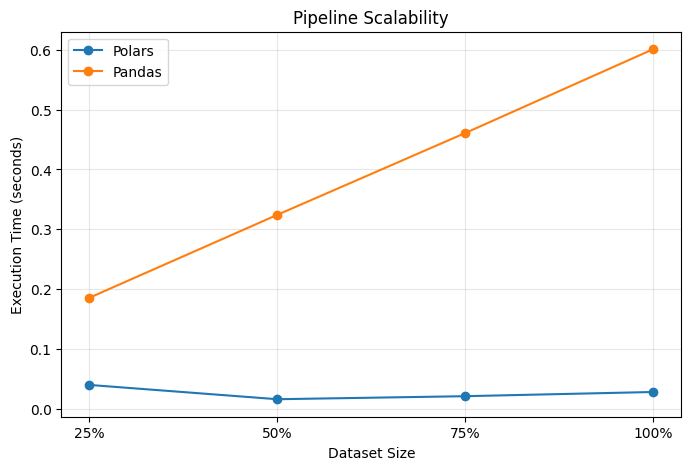

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    scalability_df["Dataset"],
    scalability_df["Polars (s)"],
    marker="o",
    label="Polars",
)

plt.plot(
    scalability_df["Dataset"],
    scalability_df["Pandas (s)"],
    marker="o",
    label="Pandas",
)

plt.xlabel("Dataset Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Pipeline Scalability")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

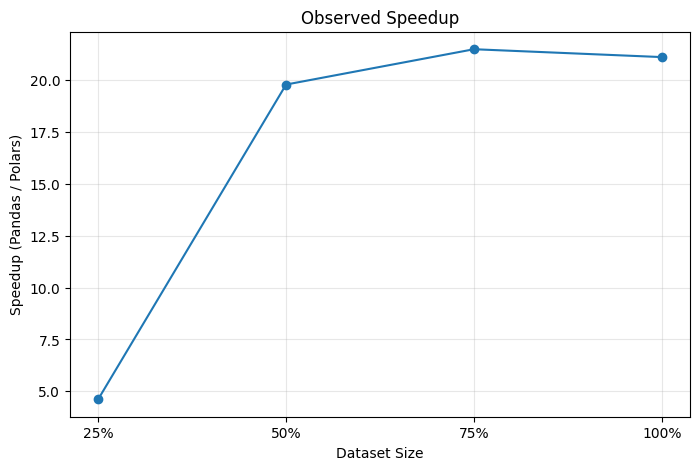

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    scalability_df["Dataset"],
    scalability_df["Speedup"],
    marker="o",
)

plt.xlabel("Dataset Size")
plt.ylabel("Speedup (Pandas / Polars)")
plt.title("Observed Speedup")

plt.grid(alpha=0.3)

plt.show()

## Lazy Execution

In [52]:
start = time.perf_counter()

eager_df = (
    pl.read_csv("../data/raw/ratings.csv")
    .filter(
        pl.col("rating") >= 4.0
    )
    .group_by("movieId")
    .agg(
        [
            pl.len().alias("num_ratings"),
            pl.col("rating")
            .mean()
            .alias("avg_rating"),
        ]
    )
)

eager_time = time.perf_counter() - start

eager_memory = eager_df.estimated_size("mb")

In [53]:
start = time.perf_counter()

lazy_df = (
    pl.scan_csv("../data/raw/ratings.csv")
    .filter(
        pl.col("rating") >= 4.0
    )
    .group_by("movieId")
    .agg(
        [
            pl.len().alias("num_ratings"),
            pl.col("rating")
            .mean()
            .alias("avg_rating"),
        ]
    )
    .collect()
)

lazy_time = time.perf_counter() - start

lazy_memory = lazy_df.estimated_size("mb")

In [54]:
lazy_results = pd.DataFrame(
    {
        "Execution Mode": [
            "Eager (read_csv)",
            "Lazy (scan_csv)",
        ],
        "Execution Time (s)": [
            eager_time,
            lazy_time,
        ],
        "Estimated Memory (MB)": [
            eager_memory,
            lazy_memory,
        ],
    }
)

lazy_results

,Execution Mode,Execution Time (s),Estimated Memory (MB)
0,Eager (read_csv),0.011434,0.120125
1,Lazy (scan_csv),0.008429,0.120125


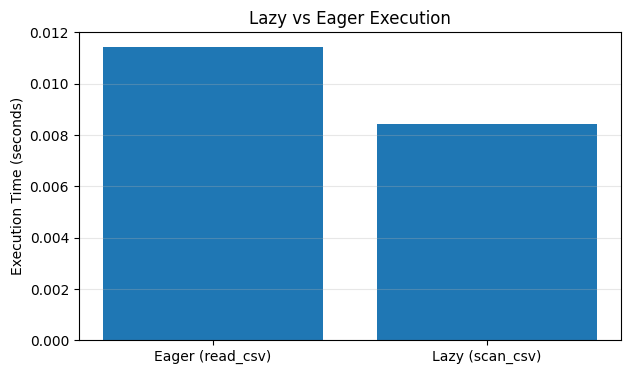

In [55]:
plt.figure(figsize=(7,4))

plt.bar(
    lazy_results["Execution Mode"],
    lazy_results["Execution Time (s)"],
)

plt.title("Lazy vs Eager Execution")
plt.ylabel("Execution Time (seconds)")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Análisis de Resultados

1. ¿Qué ventajas observó al utilizar Polars?

Durante el desarrollo del proyecto se observó que Polars ofrece una ejecución significativamente más rápida que Pandas en las etapas de preprocesamiento de datos. Operaciones como la lectura del dataset, los joins, las agregaciones mediante group_by y la ingeniería de características presentaron menores tiempos de ejecución gracias al procesamiento paralelo y al uso de Apache Arrow. Además, la sintaxis basada en expresiones facilita la construcción de pipelines reproducibles y eficientes.

2. ¿Qué operaciones obtuvieron el mayor speedup?

El mayor speedup se observó durante las etapas de agregación e ingeniería de características, donde se realizaron múltiples operaciones de group_by, joins y creación de nuevas variables. Estas operaciones son altamente optimizadas por Polars y aprovechan el paralelismo disponible en la CPU.

3. ¿En cuáles operaciones la diferencia fue pequeña?

Las diferencias fueron menores durante el entrenamiento de los modelos de Machine Learning. Esto era esperado, ya que tanto el pipeline de Polars como el de Pandas utilizan Scikit-Learn para entrenar los modelos, por lo que el procesamiento interno es exactamente el mismo independientemente de la biblioteca utilizada para preparar los datos.

4. ¿Qué beneficios aporta Lazy Execution?

Lazy Execution permite construir un plan de ejecución antes de realizar cualquier operación sobre los datos. Esto permite que Polars optimice automáticamente el pipeline, reduciendo operaciones innecesarias y ejecutando únicamente aquellas requeridas al llamar a collect(). Como resultado, se obtienen menores tiempos de ejecución y un uso más eficiente de la memoria en pipelines complejos.

5. ¿Qué limitaciones encontró en Polars?

Aunque Polars presentó un excelente rendimiento, algunas operaciones requieren una sintaxis diferente a la de Pandas y existe una menor cantidad de ejemplos y documentación disponible. Además, muchas bibliotecas de Machine Learning continúan trabajando principalmente con estructuras de Pandas o NumPy, por lo que en algunos casos es necesario convertir los datos antes del entrenamiento.

6. ¿Qué ventajas mantiene Pandas?

Pandas continúa siendo una biblioteca muy madura y ampliamente utilizada. Posee una gran comunidad, abundante documentación y compatibilidad con prácticamente todo el ecosistema de análisis de datos en Python. Para conjuntos de datos pequeños o proyectos donde el rendimiento no sea un factor crítico, Pandas sigue siendo una excelente alternativa.

7. ¿La aceleración observada justifica migrar un proyecto existente?

Depende del contexto del proyecto. Si el procesamiento de datos representa una parte importante del tiempo total de ejecución o se trabaja con grandes volúmenes de información, los resultados obtenidos muestran que la migración a Polars puede generar mejoras importantes de rendimiento. Sin embargo, para proyectos pequeños la diferencia puede no justificar el costo de migración.

8. ¿Cómo afecta el tamaño del dataset al beneficio obtenido?

Los experimentos de escalabilidad mostraron que ambos pipelines incrementan su tiempo de ejecución conforme aumenta el tamaño del conjunto de datos. No obstante, Polars mantiene tiempos considerablemente menores en todos los escenarios evaluados, por lo que el beneficio relativo se mantiene conforme crece el volumen de información procesada.

9. ¿Qué modelo produjo el mejor desempeño predictivo?

El modelo Random Forest obtuvo el mejor desempeño predictivo, alcanzando una Accuracy aproximada de 70.3 %, un F1 Score de 0.689 y un ROC AUC de 0.767. Logistic Regression y Gradient Boosting obtuvieron resultados muy similares, aunque ligeramente inferiores.

10. ¿Qué recomendaciones daría para proyectos futuros?

Para proyectos donde el preprocesamiento de datos representa una parte importante del tiempo de ejecución, se recomienda utilizar Polars como reemplazo de Pandas. También sería interesante evaluar versiones distribuidas del pipeline utilizando herramientas como Dask o Spark, así como explorar bibliotecas adicionales como XGBoost o LightGBM para mejorar el desempeño predictivo del modelo.

## Conclusiones

Durante este proyecto se implementó un pipeline completo de análisis de datos e ingeniería de características utilizando Polars y una versión equivalente utilizando Pandas, permitiendo comparar objetivamente ambas bibliotecas tanto desde el punto de vista computacional como predictivo.

Los resultados obtenidos demostraron que ambos pipelines generan exactamente el mismo conjunto de características y producen modelos de Machine Learning con métricas equivalentes, lo que confirma que las diferencias observadas corresponden únicamente al procesamiento de datos y no al entrenamiento de los modelos. Entre los algoritmos evaluados, Random Forest obtuvo el mejor desempeño predictivo con una Accuracy cercana al 70 %, seguido por Gradient Boosting y Logistic Regression.

Desde el punto de vista del rendimiento, Polars presentó tiempos de ejecución considerablemente menores que Pandas durante las etapas de lectura, joins, agregaciones e ingeniería de características. Asimismo, los experimentos de escalabilidad mostraron que esta ventaja se mantiene conforme aumenta el tamaño del conjunto de datos. La evaluación de Lazy Execution también permitió comprobar cómo la optimización automática del plan de ejecución contribuye a mejorar la eficiencia del procesamiento.

En conjunto, los resultados obtenidos muestran que Polars constituye una alternativa moderna y eficiente para el procesamiento de datos tabulares, especialmente cuando se trabaja con grandes volúmenes de información o pipelines complejos. No obstante, Pandas continúa siendo una excelente opción para proyectos pequeños gracias a su madurez, amplia documentación y compatibilidad con el ecosistema de Python.

Finalmente, este proyecto permitió aplicar de forma integrada conceptos de preprocesamiento de datos, ingeniería de características, aprendizaje automático y evaluación de rendimiento, evidenciando la importancia de seleccionar herramientas adecuadas no solo por su facilidad de uso, sino también por su impacto sobre la eficiencia computacional de los pipelines de ciencia de datos.